# Final Report - Data Science

**Important**: this report may be written in either **Portuguese or English**. However, the selected language must be used consistently throughout the entire report. Mixing Portuguese and English is not allowed.

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Larissa Alves da Silva` - `larissa.alves4@pucpr.edu.br`


# Import the libs you need

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load your data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

Dataset: reviews de jogos coletados diretamente da API pública da Steam (https://store.steampowered.com/appreviews) em 14 de setembro de 2026. A coleta foi feita em um notebook auxiliar, fora da entrega, e salva em steam_reviews_data.csv.

A API não permite baixar a base inteira, então foi feita uma amostragem por jogo: entre os 2.000 jogos com mais donos na Steam (ranking do SteamSpy), ficaram os que têm de 10 mil a 60 mil reviews em inglês, o que exclui jogos pouco avaliados e os gigantes como Counter-Strike 2. Desses, foram sorteados 30 (seed 42) e, de cada um, coletados os 5.000 reviews em inglês mais recentes publicados antes de 1º de janeiro de 2026, totalizando 150.000 instâncias. O corte de data garante uma janela mínima de oito meses entre a publicação do review e a coleta, necessária para observar se o jogador voltou a jogar. Como a API só devolve reviews do mais novo para o mais antigo, a amostra de cada jogo não é aleatória: concentra-se em 2024 e 2025.

In [3]:
df = pd.read_csv('steam_reviews_data.csv')
df

,recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,...,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,refunded,primarily_steam_deck,app_release_date
0,214447332,109600,Neverwinter,76561198015507210,0,10,4988,0,417.0,1780648487,...,1,1,0.523810,0,1,0,0,0,0,1386273660
1,214404743,109600,Neverwinter,76561198755342758,6,1,307,0,21.0,1778493660,...,1,1,0.500000,0,1,0,0,0,0,1386273660
2,214313083,109600,Neverwinter,76561197971330607,0,2,872,0,816.0,1766901804,...,1,0,0.500000,0,1,0,0,0,0,1386273660
3,214266927,109600,Neverwinter,76561199270015557,0,17,1451,0,1451.0,1753738813,...,0,0,0.500000,0,1,0,0,0,0,1386273660
4,214165173,109600,Neverwinter,76561198758078994,0,1,5051,0,1493.0,1784394474,...,0,0,0.500000,0,1,0,0,0,0,1386273660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,31874391,204300,Awesomenauts,76561198147304305,0,6,811,0,724.0,1615355638,...,0,0,0.465991,0,1,0,0,0,0,1343840400
149996,31872472,204300,Awesomenauts,76561198076710530,210,42,1741,0,1569.0,1508367795,...,1,1,0.487161,0,0,1,0,0,0,1343840400
149997,31871226,204300,Awesomenauts,76561198010442430,0,71,779,0,241.0,1542936945,...,1,0,0.523161,0,0,0,0,0,0,1343840400
149998,31870821,204300,Awesomenauts,76561198017963600,1237,20,4936,0,4402.0,1656276692,...,0,0,0.493602,0,0,1,0,0,0,1343840400


In [4]:
# remover reviews com linguagem diferente de inglês
df = df[df['language'] == 'english']

# recommendationid, author_steamid, appid: identificadores, sem valor preditivo
df.drop(['language', 'recommendationid', 'author_steamid', 'appid'], axis=1, inplace=True)

df.isna().sum()

game                                0
author_num_games_owned              0
author_num_reviews                  0
author_playtime_forever             0
author_playtime_last_two_weeks      0
author_playtime_at_review           1
author_last_played                  0
review                            593
timestamp_created                   0
timestamp_updated                   0
voted_up                            0
votes_up                            0
votes_funny                         0
weighted_vote_score                 0
comment_count                       0
steam_purchase                      0
received_for_free                   0
written_during_early_access         0
refunded                            0
primarily_steam_deck                0
app_release_date                    0
dtype: int64

In [5]:
# remover reviews sem tempo de jogo registrado
df = df.dropna(subset=['author_playtime_at_review'])

# passar timestamps para datetime e criar coluna de data de lançamento do jogo
df['created'] = pd.to_datetime(df['timestamp_created'], unit='s')
df['updated'] = pd.to_datetime(df['timestamp_updated'], unit='s')
df['release'] = pd.to_datetime(df['app_release_date'], unit='s')  

# remover reviews criadas após 2026-01-01
df = df[df['created'] < '2026-01-01']

# tempo de jogo em horas
df['playtime_hours_at_review'] = df['author_playtime_at_review'] / 60
df['playtime_hours_forever'] = df['author_playtime_forever'] / 60

df[['created', 'release', 'playtime_hours_at_review', 'playtime_hours_forever']].describe()

,created,release,playtime_hours_at_review,playtime_hours_forever
count,149971,149971,149971.000000,149971.000000
mean,2024-02-10 04:58:44,2017-01-23 22:04:53,126.264993,198.546684
min,2017-05-20 22:47:07,2008-11-18 21:00:00,0.016667,0.083333
25%,2023-05-10 14:05:30,2013-12-05 20:01:00,7.166667,14.016667
50%,2024-07-13 17:41:39,2015-09-17 16:00:00,21.866667,38.333333
75%,2025-05-20 09:48:04,2021-02-10 23:00:00,68.966667,119.000000
max,2025-12-31 23:58:36,2025-07-22 17:37:57,47796.400000,68765.016667
std,NaN,NaN,548.113556,778.824847


In [6]:
# remover reviews sem texto
df = df[df['review'].notna() & (df['review'].str.strip() != '')].reset_index(drop=True)

# conteúdo que vai ser usado como features de texto
df['review_len'] = df['review'].str.len()
df['review_words'] = df['review'].str.split().str.len()
df['review_edited'] = (df['timestamp_updated'] != df['timestamp_created']).astype(int)
df['has_exclamation'] = df['review'].str.contains('!', regex=False).astype(int)
df['has_question'] = df['review'].str.contains('?', regex=False).astype(int)
df['caps_ratio'] = df['review'].str.count(r'[A-Z]') / df['review_len']

# coisas que são mencionadas na review e podem ser relevantes para o problema
df['mentions_bug'] = df['review'].str.contains(r'bug|crash|glitch', case=False).astype(int)
df['mentions_refund'] = df['review'].str.contains(r'refund', case=False).astype(int)
df['mentions_update'] = df['review'].str.contains(r'update|patch', case=False).astype(int)
df['mentions_boring'] = df['review'].str.contains(r'boring|repetitive', case=False).astype(int)

df[['review_len', 'review_words', 'caps_ratio']].describe()

,review_len,review_words,caps_ratio
count,149337.000000,149337.000000,149337.000000
mean,217.820540,39.217300,0.058144
std,536.181686,93.918459,0.146877
min,1.000000,1.000000,0.000000
25%,17.000000,3.000000,0.000000
50%,55.000000,10.000000,0.019569
75%,183.000000,33.000000,0.043478
max,8000.000000,1668.000000,1.000000


In [7]:
# features de tempo
df['created_year'] = df['created'].dt.year
df['created_month'] = df['created'].dt.month
df['created_weekday'] = df['created'].dt.weekday
df['created_hour'] = df['created'].dt.hour

# dias entre a criação do review e a data de coleta (2026-09-14)
df['days_to_collection'] = (pd.Timestamp('2026-09-14') - df['created']).dt.days

# idade do jogo no momento do review, em anos
df['game_age_years'] = ((df['created'] - df['release']).dt.days / 365.25).round(2)

df[['created_year', 'days_to_collection', 'game_age_years']].describe()

,created_year,days_to_collection,game_age_years
count,149337.000000,149337.000000,149337.000000
mean,2023.561502,946.495195,7.041171
std,1.681425,621.443571,4.036519
min,2017.000000,256.000000,0.100000
25%,2023.000000,481.000000,4.090000
50%,2024.000000,792.000000,6.520000
75%,2025.000000,1222.000000,10.170000
max,2025.000000,3403.000000,17.120000


In [8]:
# features relacionadas ao autor do review
df['reviews_per_game'] = df['author_num_reviews'] / df['author_num_games_owned'].replace(0, np.nan)
df['profile_hidden'] = (df['author_num_games_owned'] == 0).astype(int)   # perfil privado ou sem jogos
df['reviewed_before_playing'] = (df['author_playtime_at_review'] == 0).astype(int)
df['votes_total'] = df['votes_up'] + df['votes_funny']

df[['reviews_per_game', 'profile_hidden', 'reviewed_before_playing']].describe()

,reviews_per_game,profile_hidden,reviewed_before_playing
count,68777.000000,149337.000000,149337.0
mean,0.208544,0.539451,0.0
std,0.647551,0.498443,0.0
min,0.000228,0.000000,0.0
25%,0.051672,0.000000,0.0
50%,0.118644,1.000000,0.0
75%,0.250000,1.000000,0.0
max,65.842105,1.000000,0.0


In [9]:
# features relacionadas ao target
df['playtime_after_hours'] = df['playtime_hours_forever'] - df['playtime_hours_at_review']

# remover reviews com playtime_after_hours negativo
df = df[df['playtime_after_hours'] >= 0].reset_index(drop=True)

df['continued'] = (df['playtime_after_hours'] >= 2).astype(int)
df['continued'].value_counts(normalize=True)

continued
1    0.608529
0    0.391471
Name: proportion, dtype: float64

In [10]:
# colunas que descrevem o comportamento DEPOIS do review: só serviram pra construir o alvo (leakage)
leakage = ['author_playtime_forever', 'author_playtime_last_two_weeks', 'author_last_played',
           'playtime_hours_forever', 'playtime_after_hours', 'refunded']

# colunas originais que já foram convertidas pra outra unidade
redundantes = ['timestamp_created', 'timestamp_updated', 'author_playtime_at_review', 'app_release_date']

df.drop(columns=leakage + redundantes, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149319 entries, 0 to 149318
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype        
---  ------                       --------------   -----        
 0   game                         149319 non-null  str          
 1   author_num_games_owned       149319 non-null  int64        
 2   author_num_reviews           149319 non-null  int64        
 3   review                       149319 non-null  str          
 4   voted_up                     149319 non-null  int64        
 5   votes_up                     149319 non-null  int64        
 6   votes_funny                  149319 non-null  int64        
 7   weighted_vote_score          149319 non-null  float64      
 8   comment_count                149319 non-null  int64        
 9   steam_purchase               149319 non-null  int64        
 10  received_for_free            149319 non-null  int64        
 11  written_during_early_access  149319 non-null  int6

**Resumo da etapa de preparação**

Base final: 149.319 reviews de 30 jogos. Saíram 681 linhas: 634 reviews vazios, 27 de 1º de janeiro de 2026 que escaparam do corte por fuso horário, 18 com tempo de jogo negativo após o review (erro da API), 1 em italiano e 1 sem tempo de jogo registrado.

O alvo continued vale 1 quando o autor jogou pelo menos 2 horas depois de publicar o review, o mesmo limiar da política de reembolso da Steam.

As colunas que descrevem o comportamento depois do review (author_playtime_forever, author_playtime_last_two_weeks, author_last_played, playtime_hours_forever, playtime_after_hours e refunded) serviram só para construir o alvo e foram removidas, caso contrário o modelo acertaria 100%. Também saíram as colunas brutas já convertidas em datetime e horas.

Restam 33 features tabulares, mais review, as datas created, updated e release, e o alvo. reviews_per_game tem NaN em 54% das linhas porque perfis ocultos aparecem com zero jogos; profile_hidden registra isso e o preenchimento fica para a fase de modelagem.

# Statistical Description

In this section, you should report the key characteristics of the dataset, including but not limited to:
* the number of instances;
* the number of features;
* the type of target variable or task;
* the number of classes, for classification problems;
* the class distribution, for classification problems;
* the distribution and range of the target variable, for regression problems.

In [11]:
df.shape

(149319, 38)

In [12]:
df.dtypes.value_counts()

int64            24
float64           5
int32             4
datetime64[s]     3
str               2
Name: count, dtype: int64

In [13]:
# distribuição das classes do alvo em contagem absoluta
df['continued'].value_counts()

continued
1    90865
0    58454
Name: count, dtype: int64

In [14]:
# distribuição das classes do alvo em proporção
df['continued'].value_counts(normalize=True)

continued
1    0.608529
0    0.391471
Name: proportion, dtype: float64

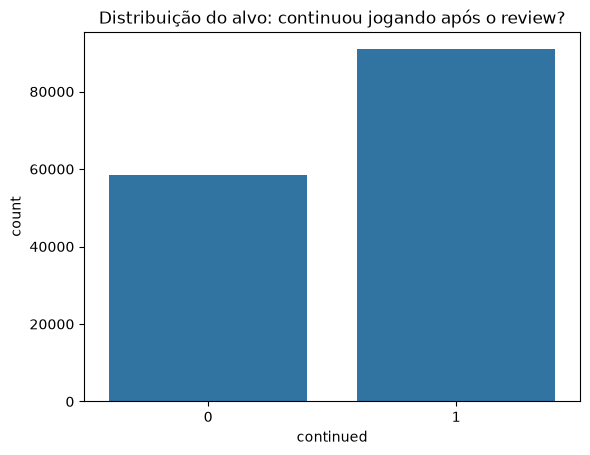

In [15]:
# visualização do desbalanceamento entre as classes
sns.countplot(data=df, x='continued')
plt.title('Distribuição do alvo: continuou jogando após o review?')
plt.show()

In [16]:
# quantidade de reviews por jogo após a limpeza
df['game'].value_counts()

game
Terminator: Resistance                                     4992
Stoneshard                                                 4990
Dwarf Fortress                                             4988
Abiotic Factor                                             4986
Yakuza Kiwami                                              4986
Awesomenauts                                               4986
Train Simulator Classic                                    4982
Counter-Strike Nexon: Studio                               4982
Neverwinter                                                4981
Dorfromantik                                               4981
DOOM: The Dark Ages                                        4981
Days Gone                                                  4980
Sleeping Dogs: Definitive Edition                          4979
Thief Simulator                                            4979
Squad 44                                                   4979
Realm of the Mad God Exalt         

In [17]:
# proporção de jogadores que continuaram jogando após o review por jogo
df.groupby('game')['continued'].mean().sort_values()

game
Little Nightmares II                                       0.300623
Yakuza Kiwami                                              0.432812
Terminator: Resistance                                     0.435497
S.T.A.L.K.E.R.: Call of Pripyat                            0.452386
Dishonored 2                                               0.469782
Sleeping Dogs: Definitive Edition                          0.485841
AdVenture Capitalist                                       0.522782
Thief Simulator                                            0.524001
The Binding of Isaac                                       0.527744
Awesomenauts                                               0.544124
Trove                                                      0.550864
Days Gone                                                  0.557229
Assassin's Creed Unity                                     0.565803
Counter-Strike Nexon: Studio                               0.570454
Call of Duty: World at War                 

In [18]:
# estatísticas descritivas das colunas numéricas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
author_num_games_owned,149319.0,145.751632,0.0,0.0,0.0,135.0,32502.0,581.92406
author_num_reviews,149319.0,38.561529,1.0,4.0,10.0,29.0,26464.0,395.337728
voted_up,149319.0,0.861357,0.0,1.0,1.0,1.0,1.0,0.345575
votes_up,149319.0,2.01906,0.0,0.0,0.0,1.0,789.0,13.138233
votes_funny,149319.0,0.405575,0.0,0.0,0.0,0.0,616.0,4.484913
weighted_vote_score,149319.0,0.506389,0.104312,0.5,0.5,0.5,0.974108,0.044939
comment_count,149319.0,0.102083,0.0,0.0,0.0,0.0,121.0,0.871124
steam_purchase,149319.0,0.852356,0.0,1.0,1.0,1.0,1.0,0.354748
received_for_free,149319.0,0.03747,0.0,0.0,0.0,0.0,1.0,0.189911
written_during_early_access,149319.0,0.033418,0.0,0.0,0.0,0.0,1.0,0.179727


A base tem 149.319 instâncias e 38 colunas: 33 features, o alvo, o texto bruto do review e três datas. A maioria das features é inteira (binárias, contagens e campos de data), cinco são contínuas.

Os 30 jogos têm entre 4.960 e 4.992 reviews cada, então a amostra segue balanceada por jogo. A taxa de retenção, porém, varia bastante entre eles: de 30% em Little Nightmares II a 84% em SnowRunner. Jogos de simulação e sandbox ocupam o topo e jogos lineares curtos ficam na base, o que sugere que o tipo de jogo e sua duração pesam no alvo.

O `describe()` mostra caudas longas em `playtime_hours_at_review`, `votes_up`, `review_len` e a `uthor_num_games_owned`, com médias muito acima das medianas e máximos extremos, como 47.796 horas de jogo em um único review.

# Univariate data analysis

In this section, you should perform univariate data analysis on at least **20 variables**.

In the end, you should describe the main variables that are of your interest, and these should be accounted for in the next sections of the report.
The definition of each variable chosen should be clarified, so arbitrary selections are **not** accepted at this point.

For each variable plotted, make sure you determine the following:
1. The distribution of the data (Gaussian, binomial, exponential, etc.);
2. Skewness;
3. Kurtosis;
4. Mean, standard deviation, and what they stand for in the context of the dataset.

Ensure that each variable is **plotted correctly** based on its type. For instance, make sure scatterplots are not used for categorical data and so forth.

As 21 variáveis escolhidas cobrem os cinco grupos de informação disponíveis no momento em que o review é publicado: o alvo e o contexto da avaliação, o perfil do autor, o engajamento que o review gerou, o conteúdo do texto e o tempo.

As variáveis binárias usam countplot. As contínuas de cauda longa foram agrupadas em faixas que multiplicam a anterior por um valor fixo, para que a altura das barras seja comparável entre si. A categórica game usa countplot horizontal, porque são 30 nomes.

continued
1    0.608529
0    0.391471
Name: proportion, dtype: float64
skew: -0.44 | curtose: -1.8


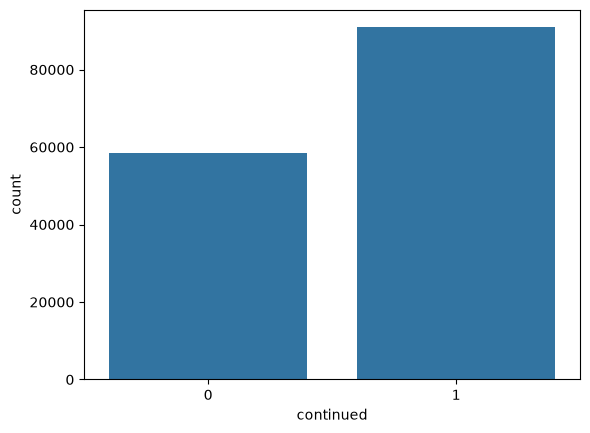

In [19]:
# alvo: jogou pelo menos 2 horas depois de publicar o review
sns.countplot(data=df, x='continued')
print(df['continued'].value_counts(normalize=True))
print('skew:', round(df['continued'].skew(), 2), '| curtose:', round(df['continued'].kurt(), 2))

**continued**: **Bernoulli** com p igual a 0,61, **assimetria** −0,44 e **curtose** −1,80. **Média** 0,61 é a própria taxa de retenção e **desvio padrão** 0,49 é quase o máximo de uma binária, ou seja, o alvo varia muito e não é trivial de prever.

voted_up
1    0.861357
0    0.138643
Name: proportion, dtype: float64
skew: -2.09 | curtose: 2.37


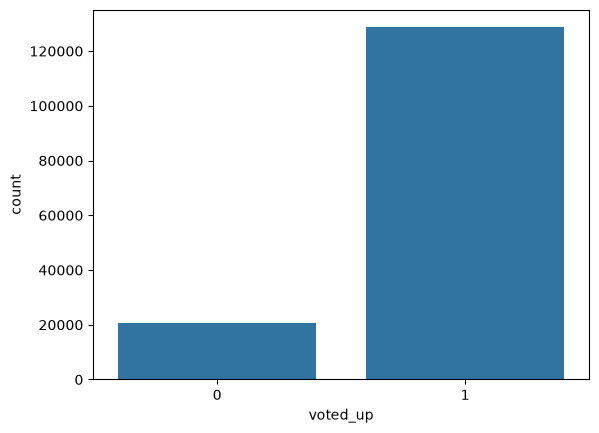

In [ ]:
# o autor recomenda o jogo (1) ou não (0)
sns.countplot(data=df, x='voted_up')
print(df['voted_up'].value_counts(normalize=True))
print('skew:', round(df['voted_up'].skew(), 2), '| curtose:', round(df['voted_up'].kurt(), 2))

**voted_up**: **Bernoulli** com p igual a 0,86, **assimetria** −2,09 e **curtose** 2,37. **Média** 0,86 e **desvio padrão** 0,35: a maioria recomenda, mas os 14% negativos ainda somam cerca de 20.700 reviews.

steam_purchase
1    0.852356
0    0.147644
Name: proportion, dtype: float64
skew: -1.99 | curtose: 1.95


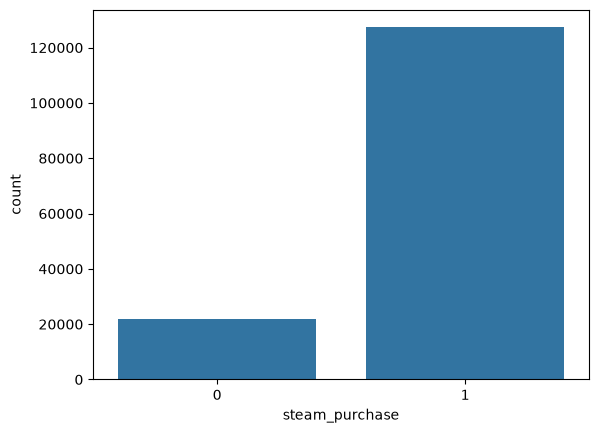

In [21]:
# jogo comprado na própria Steam (1) ou ativado por chave externa (0)
sns.countplot(data=df, x='steam_purchase')
print(df['steam_purchase'].value_counts(normalize=True))
print('skew:', round(df['steam_purchase'].skew(), 2), '| curtose:', round(df['steam_purchase'].kurt(), 2))

**steam_purchase**: **Bernoulli** com p igual a 0,85, **assimetria** −1,99 e **curtose** 1,95. **Média** 0,85 e **desvio padrão** 0,35: 15% chegaram por chave externa e tiveram custo de aquisição diferente.

received_for_free
0    0.96253
1    0.03747
Name: proportion, dtype: float64
skew: 4.87 | curtose: 21.73


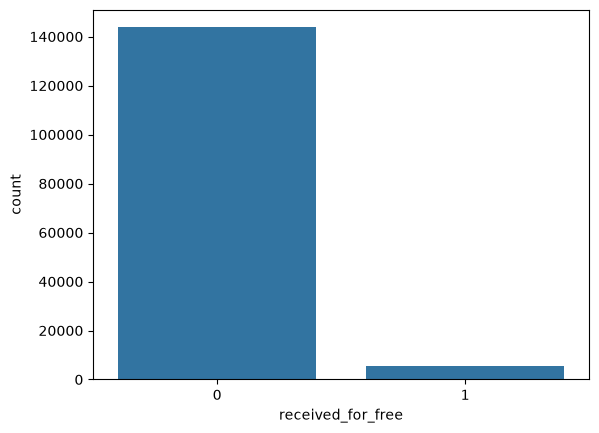

In [22]:
# jogador declarou ter recebido o jogo de graça (1) ou não (0)
sns.countplot(data=df, x='received_for_free')
print(df['received_for_free'].value_counts(normalize=True))
print('skew:', round(df['received_for_free'].skew(), 2), '| curtose:', round(df['received_for_free'].kurt(), 2))

**received_for_free**: **Bernoulli** com p igual a 0,04, **assimetria** 4,87 e **curtose** 21,73. **Média** 0,04 e **desvio padrão** 0,19: são cerca de 5.600 reviews, minoria pequena mas suficiente para comparação.

written_during_early_access
0    0.966582
1    0.033418
Name: proportion, dtype: float64
skew: 5.19 | curtose: 24.96


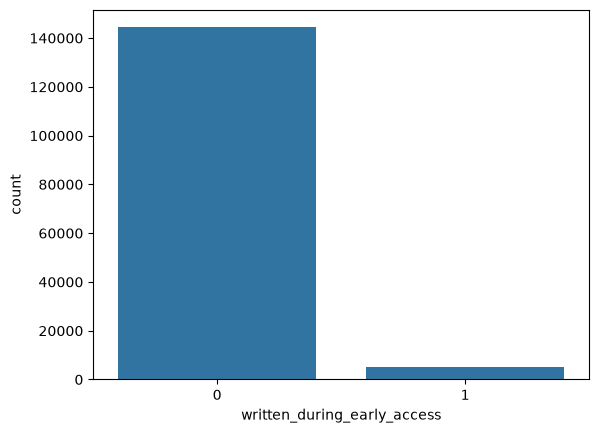

In [23]:
# review escrito enquanto o jogo estava em acesso antecipado (1) ou não (0)
sns.countplot(data=df, x='written_during_early_access')
print(df['written_during_early_access'].value_counts(normalize=True))
print('skew:', round(df['written_during_early_access'].skew(), 2), '| curtose:', round(df['written_during_early_access'].kurt(), 2))

**written_during_early_access**: **Bernoulli** com p igual a 0,03, **assimetria** 5,19 e **curtose** 24,96. **Média** 0,03 e **desvio padrão** 0,18: cerca de 4.990 reviews, concentrados nos poucos jogos que passaram por acesso antecipado.

count    149319.000000
mean        946.375143
std         621.341219
min         256.000000
25%         481.000000
50%         792.000000
75%        1222.000000
max        3403.000000
Name: days_to_collection, dtype: float64
skew: 1.49 | curtose: 2.43


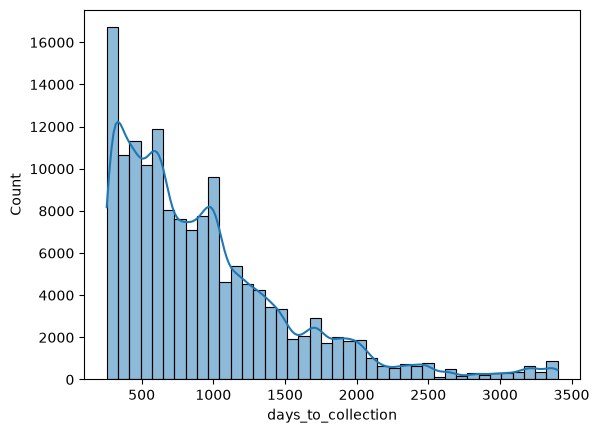

In [24]:
# dias entre a publicação do review e a coleta dos dados (14/09/2026)
sns.histplot(data=df, x='days_to_collection', kde=True, bins=40)
print(df['days_to_collection'].describe())
print('skew:', round(df['days_to_collection'].skew(), 2), '| curtose:', round(df['days_to_collection'].kurt(), 2))

**days_to_collection**: Assimétrica à direita, **assimetria** 1,49 e **curtose** 2,43. **Média** 946 dias e **desvio padrão** 621 contra **mediana** 792: a data de coleta é a mesma para todos, 14/09/2026, mas cada review foi escrito em um momento diferente, então a janela vai de 256 a 3.403 dias.

count    68771.000000
mean       316.463160
std        825.374749
min          1.000000
25%         69.000000
50%        153.000000
75%        330.000000
max      32502.000000
Name: author_num_games_owned, dtype: float64
skew: 31.62 | curtose: 1574.21


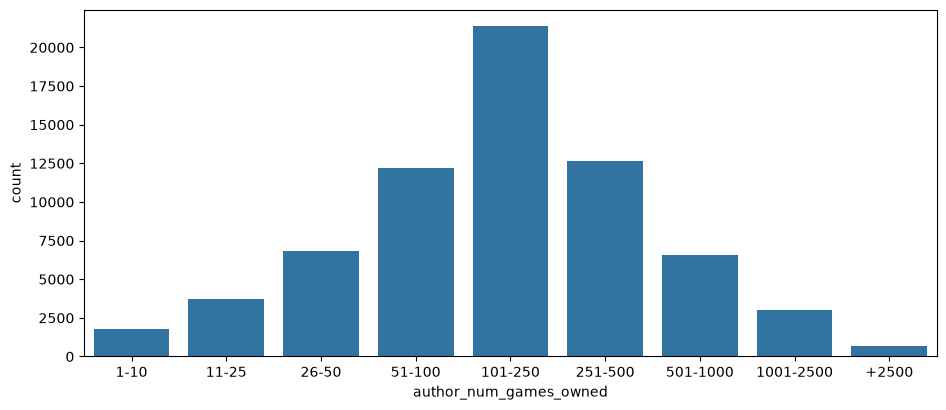

In [25]:
# quantidade de jogos que o usuário público possui na Steam, em faixas
faixas = pd.cut(df[df['author_num_games_owned'] > 0]['author_num_games_owned'],
                [0, 10, 25, 50, 100, 250, 500, 1000, 2500, 100000],
                labels=['1-10', '11-25', '26-50', '51-100', '101-250', '251-500', '501-1000', '1001-2500', '+2500'])
plt.figure(figsize=(11, 4.5))
sns.countplot(x=faixas)
print(df[df['author_num_games_owned'] > 0]['author_num_games_owned'].describe())
print('skew:', round(df['author_num_games_owned'].skew(), 2), '| curtose:', round(df['author_num_games_owned'].kurt(), 2))

**author_num_games_owned**: Cauda longa à direita, próxima de log-normal. **Assimetria** 31,6 e **curtose** 1.574 ficam infladas pelos 54% de zeros, que são perfis privados. Entre os públicos a **média** é 316 e o **desvio padrão** 825 contra **mediana** 153

count    149319.000000
mean         38.561529
std         395.337728
min           1.000000
25%           4.000000
50%          10.000000
75%          29.000000
max       26464.000000
Name: author_num_reviews, dtype: float64
skew: 57.16 | curtose: 3582.48


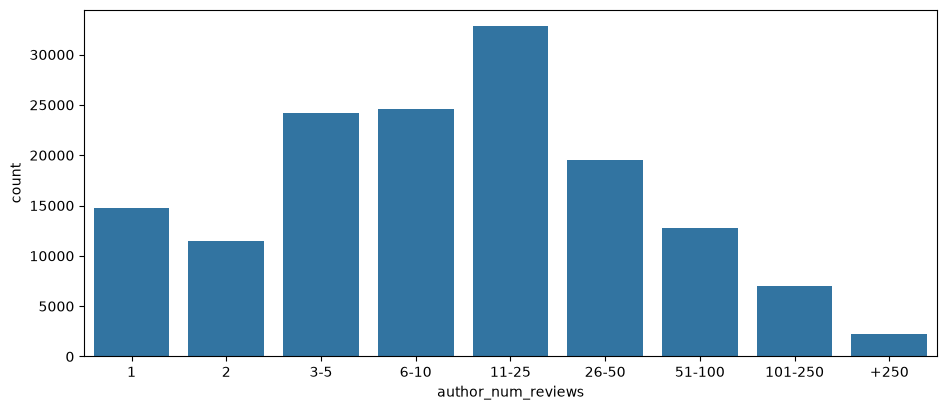

In [26]:
# quantos reviews o usuário já escreveu na Steam, em faixas
faixas = pd.cut(df['author_num_reviews'], [0, 1, 2, 5, 10, 25, 50, 100, 250, 100000],
                labels=['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '101-250', '+250'])
plt.figure(figsize=(11, 4.5))
sns.countplot(x=faixas)
print(df['author_num_reviews'].describe())
print('skew:', round(df['author_num_reviews'].skew(), 2), '| curtose:', round(df['author_num_reviews'].kurt(), 2))

**author_num_reviews**: Cauda longa à direita, **assimetria** 57,2 e **curtose** 3.582. **Média** 38,6 e **desvio** 395 contra **mediana** 10: a média é puxada por poucas contas extremas e não representa o autor típico.

profile_hidden
1    0.539436
0    0.460564
Name: proportion, dtype: float64
skew: -0.16 | curtose: -1.97


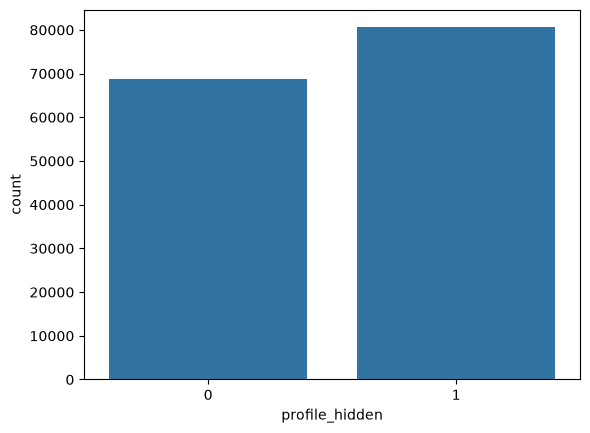

In [27]:
# perfil do autor é privado (1) ou público (0)
sns.countplot(data=df, x='profile_hidden')
print(df['profile_hidden'].value_counts(normalize=True))
print('skew:', round(df['profile_hidden'].skew(), 2), '| curtose:', round(df['profile_hidden'].kurt(), 2))

**profile_hidden**: **Bernoulli** com p igual a 0,54, a mais equilibrada do conjunto, **assimetria** −0,16 e **curtose** −1,97. **Média** 0,54 e **desvio padrão** 0,50: metade dos autores não expõe a biblioteca, o que explica os vazios em author_num_games_owned e reviews_per_game.

count    68771.000000
mean         0.208537
std          0.647568
min          0.000228
25%          0.051679
50%          0.118644
75%          0.250000
max         65.842105
Name: reviews_per_game, dtype: float64
skew: 67.38 | curtose: 6342.14


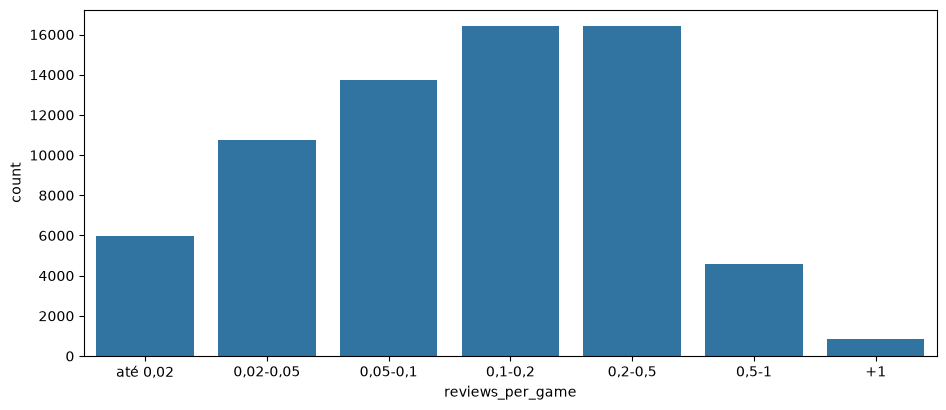

In [28]:
# reviews escritos por jogo possuído utilizando usuários públicos, em faixas
faixas = pd.cut(df['reviews_per_game'], [0, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 1000],
                labels=['até 0,02', '0,02-0,05', '0,05-0,1', '0,1-0,2', '0,2-0,5', '0,5-1', '+1'])
plt.figure(figsize=(11, 4.5))
sns.countplot(x=faixas)
print(df['reviews_per_game'].describe())
print('skew:', round(df['reviews_per_game'].skew(), 2), '| curtose:', round(df['reviews_per_game'].kurt(), 2))

**reviews_per_game**: Cauda longa extrema, **assimetria** 67,4 e **curtose** 6.342, definida só nos 68.771 perfis públicos. **Média** 0,21 e **desvio padrão** 0,65 contra **mediana** 0,12: o autor típico escreve um review a cada oito jogos que possui.

count    149319.000000
mean        126.366109
std         548.770585
min           0.016667
25%           7.183333
50%          21.900000
75%          69.041667
max       47796.400000
Name: playtime_hours_at_review, dtype: float64
skew: 20.96 | curtose: 913.46


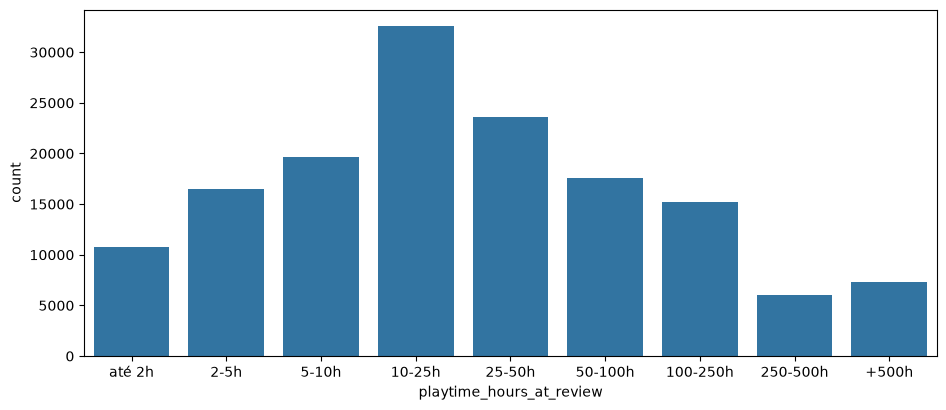

In [29]:
# horas jogadas até o review, em faixas (o primeiro corte é o limite de reembolso da Steam)
faixas = pd.cut(df['playtime_hours_at_review'], [0, 2, 5, 10, 25, 50, 100, 250, 500, 100000],
                labels=['até 2h', '2-5h', '5-10h', '10-25h', '25-50h', '50-100h', '100-250h', '250-500h', '+500h'])
plt.figure(figsize=(11, 4.5))
sns.countplot(x=faixas)
print(df['playtime_hours_at_review'].describe())
print('skew:', round(df['playtime_hours_at_review'].skew(), 2), '| curtose:', round(df['playtime_hours_at_review'].kurt(), 2))

**playtime_hours_at_review**: Assimétrica à direita com cauda extrema, **assimetria** 21,0 e **curtose** 913. **Média** 126 horas e **desvio padrão** 549 contra **mediana** 21,9: a média descreve a cauda, não o jogador típico.

skew do log: 0.02 | curtose do log: 0.48


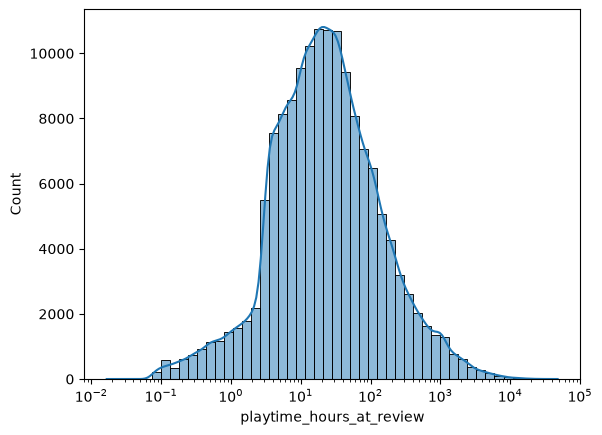

In [30]:
# mostra a distribuição do tempo de jogo até o review em escala logarítmica
sns.histplot(data=df, x='playtime_hours_at_review', log_scale=True, kde=True, bins=50)
print('skew do log:', round(np.log10(df['playtime_hours_at_review']).skew(), 2),
      '| curtose do log:', round(np.log10(df['playtime_hours_at_review']).kurt(), 2))

**playtime_hours_at_review** em **log**: Em escala logarítmica vira quase uma **gaussiana**, com **assimetria** 0,02 e **curtose** 0,48, o que caracteriza uma distribuição log-normal. É a única contínua bem comportada após transformação, e por isso a mais confiável para a modelagem.

count    149319.000000
mean        217.819614
std         536.205217
min           1.000000
25%          17.000000
50%          55.000000
75%         183.000000
max        8000.000000
Name: review_len, dtype: float64
skew: 6.74 | curtose: 64.3


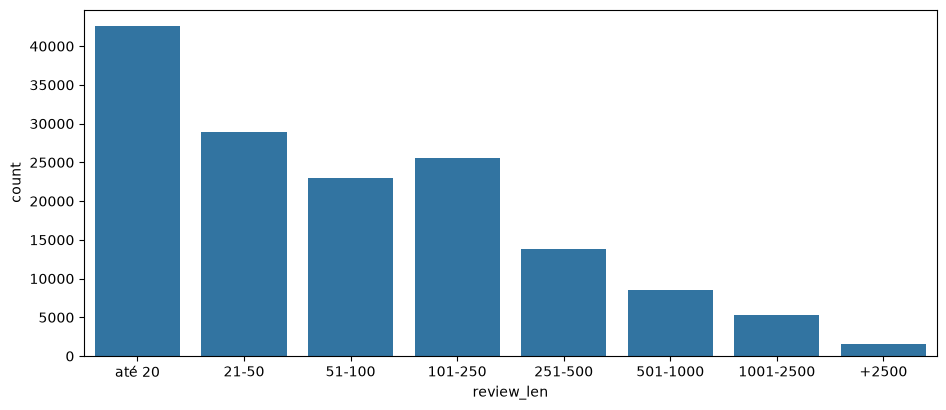

In [31]:
# tamanho do review em caracteres, em faixas
faixas = pd.cut(df['review_len'], [0, 20, 50, 100, 250, 500, 1000, 2500, 100000],
                labels=['até 20', '21-50', '51-100', '101-250', '251-500', '501-1000', '1001-2500', '+2500'])
plt.figure(figsize=(11, 4.5))
sns.countplot(x=faixas)
print(df['review_len'].describe())
print('skew:', round(df['review_len'].skew(), 2), '| curtose:', round(df['review_len'].kurt(), 2))

**review_len**: Assimétrica à direita, próxima de log-normal, **assimetria** 6,74 e **curtose** 64,3. **Média** 218 caracteres e **desvio padrão** 536 contra **mediana** 55: mais de um quarto da base escreve até 20 caracteres.

jogos: 30
min    4960
max    4992
Name: count, dtype: int64


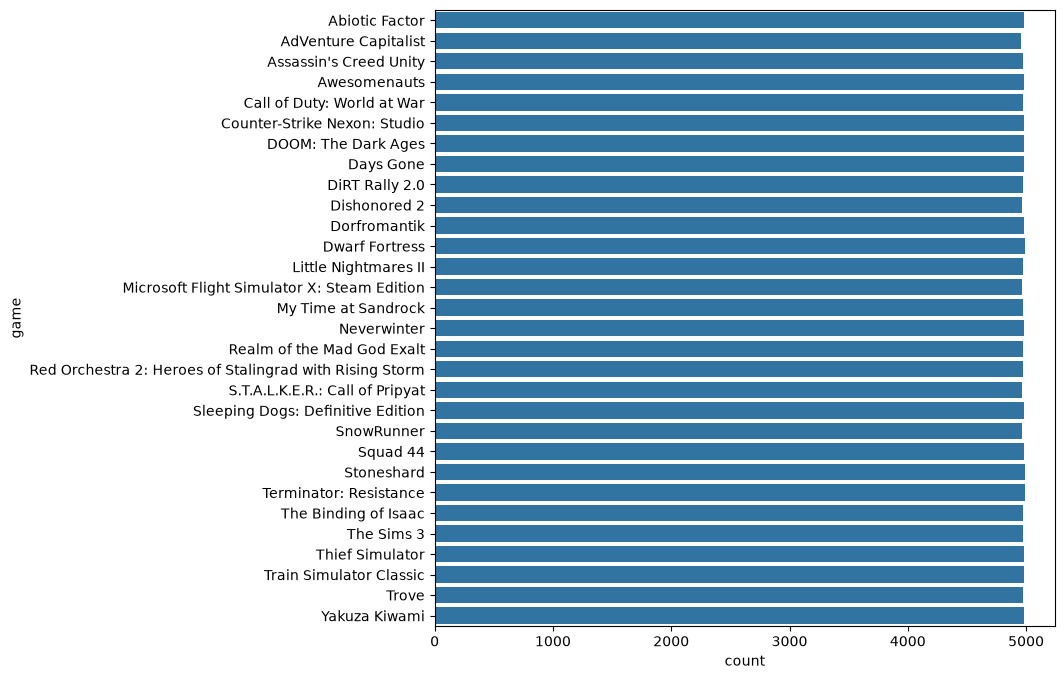

In [32]:
# jogo avaliado: variável categórica com 30 valores possíveis
plt.figure(figsize=(8, 8))
sns.countplot(data=df, y='game', order=sorted(df['game'].unique()))
print('jogos:', df['game'].nunique())
print(df['game'].value_counts().agg(['min', 'max']))

**game**: Categórica nominal com 30 valores, de 4.960 a 4.992 reviews cada. Assimetria, curtose, média e desvio não se aplicam, porque a variável não tem ordem nem escala. A uniformidade vem do desenho amostral, e o que interessa é a retenção por jogo, de 30% a 84%, que fica para a multivariada.

count    149319.000000
mean          0.102083
std           0.871124
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         121.000000
Name: comment_count, dtype: float64
skew: 47.44 | curtose: 4345.74


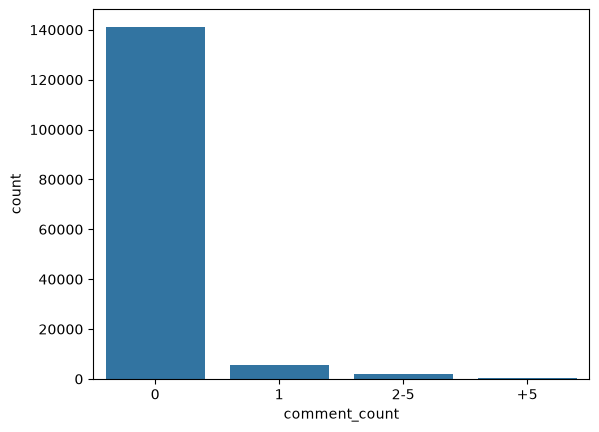

In [33]:
# quantos comentários o review recebeu, em faixas
faixas = pd.cut(df['comment_count'], [-1, 0, 1, 5, 100000], labels=['0', '1', '2-5', '+5'])
sns.countplot(x=faixas)
print(df['comment_count'].describe())
print('skew:', round(df['comment_count'].skew(), 2), '| curtose:', round(df['comment_count'].kurt(), 2))

**comment_count**: Inflada de zeros, com 94,5% dos reviews sem nenhum comentário, **assimetria** 47,4 e **curtose** 4.346. **Média** 0,10 e **desvio padrão** 0,87: quase binária e rara demais para sustentar cruzamentos.

review_edited
0    0.898312
1    0.101688
Name: proportion, dtype: float64
skew: 2.64 | curtose: 4.95


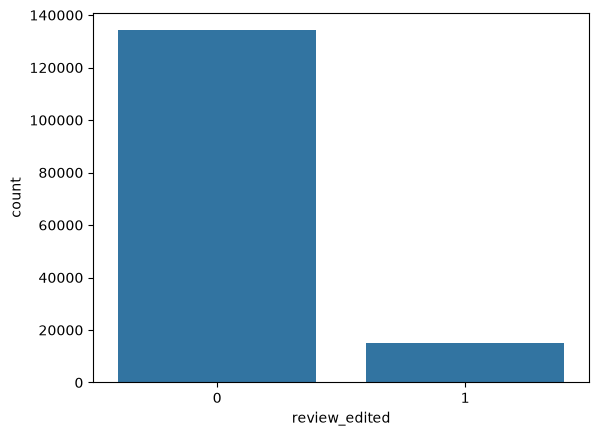

In [34]:
# review foi editado após a publicação (1) ou não (0)
sns.countplot(data=df, x='review_edited')
print(df['review_edited'].value_counts(normalize=True))
print('skew:', round(df['review_edited'].skew(), 2), '| curtose:', round(df['review_edited'].kurt(), 2))

**review_edited**: **Bernoulli** com p igual a 0,10, **assimetria** 2,64 e **curtose** 4,95. **Média** 0,10 e **desvio** 0,30: editar exige voltar à página do jogo, então é candidata a indicar vínculo continuado com o título.

mentions_bug
0    0.959235
1    0.040765
Name: proportion, dtype: float64
skew: 4.64 | curtose: 19.57


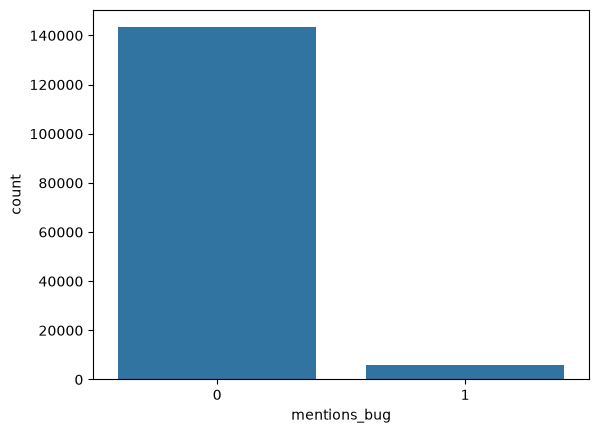

In [35]:
# review menciona bug, crash ou glitch (1) ou não (0)
sns.countplot(data=df, x='mentions_bug')
print(df['mentions_bug'].value_counts(normalize=True))
print('skew:', round(df['mentions_bug'].skew(), 2), '| curtose:', round(df['mentions_bug'].kurt(), 2))

**mentions_bug**: **Bernoulli** com p igual a 0,04, **assimetria** 4,64 e **curtose** 19,57. **Média** 0,04 e **desvio padrão** 0,20: é a única variável de conteúdo semântico entre as escolhidas.

count    149319.000000
mean       2023.561831
std           1.681127
min        2017.000000
25%        2023.000000
50%        2024.000000
75%        2025.000000
max        2025.000000
Name: created_year, dtype: float64
skew: -1.57 | curtose: 2.69


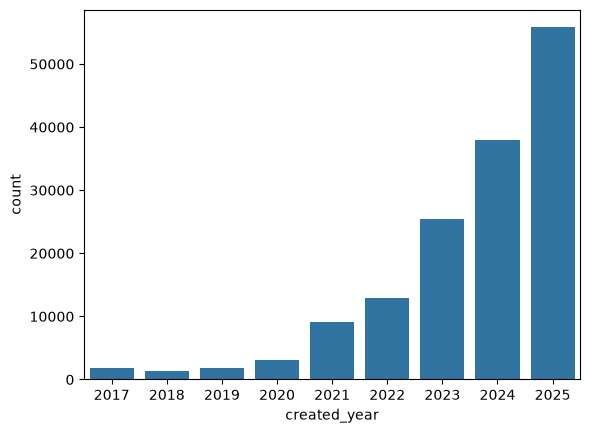

In [36]:
# ano de publicação do review
sns.countplot(data=df, x='created_year')
print(df['created_year'].describe())
print('skew:', round(df['created_year'].skew(), 2), '| curtose:', round(df['created_year'].kurt(), 2))

**created_year**: Assimétrica à esquerda, **assimetria** −1,57 e **curtose** 2,69. **Média** 2023,6 e **desvio padrão** 1,68: 2025 sozinho responde por 37,4% da base, forma que reflete o desenho da coleta e não o crescimento da Steam.

count    149319.000000
mean          3.087691
std           2.034629
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: created_weekday, dtype: float64
skew: -0.05 | curtose: -1.29


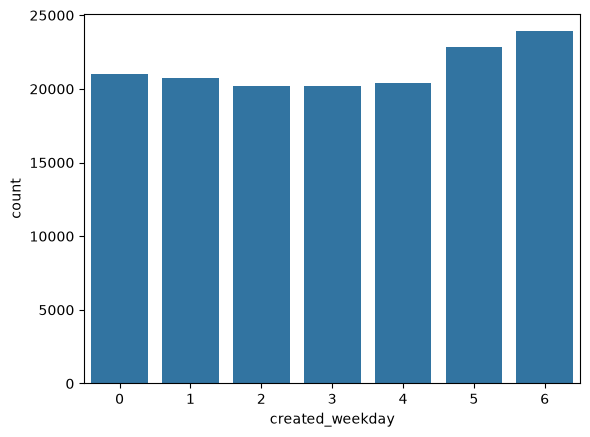

In [37]:
# dia da semana do review (0 = segunda, 6 = domingo)
sns.countplot(data=df, x='created_weekday')
print(df['created_weekday'].describe())
print('skew:', round(df['created_weekday'].skew(), 2), '| curtose:', round(df['created_weekday'].kurt(), 2))

**created_weekday**: Praticamente uniforme, **assimetria** −0,05 e curtose −1,29. **Média** 3,09 e **desvio padrão** 2,03: sábado e domingo somam 31,3% contra os 28,6% esperados, diferença pequena.

count    149319.000000
mean          7.040999
std           4.036596
min           0.100000
25%           4.090000
50%           6.520000
75%          10.170000
max          17.120000
Name: game_age_years, dtype: float64
skew: 0.29 | curtose: -0.65


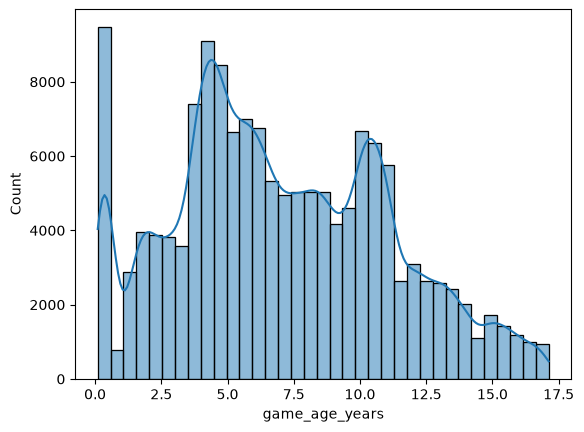

In [38]:
# idade do jogo (anos desde o lançamento) no momento do review
sns.histplot(data=df, x='game_age_years', kde=True, bins=35)
print(df['game_age_years'].describe())
print('skew:', round(df['game_age_years'].skew(), 2), '| curtose:', round(df['game_age_years'].kurt(), 2))

**game_age_years**: Multimodal, com um pico por jogo, **assimetria** 0,29 e **curtose** −0,65. **Média** 7,0 anos e **desvio padrão** 4,0, indo de 0,1 a 17,1: mede a idade do jogo quando o review foi escrito.

count    149319.000000
mean          2.019060
std          13.138233
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         789.000000
Name: votes_up, dtype: float64
skew: 22.55 | curtose: 806.47


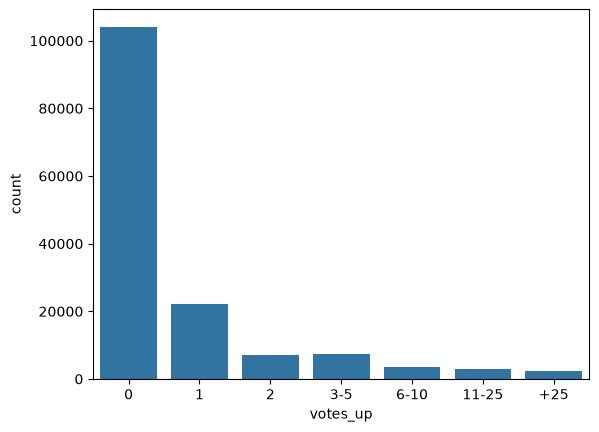

In [ ]:
# quantos leitores marcaram o review como útil (é reação de quem leu, não a opinião do autor)
faixas = pd.cut(df['votes_up'], [-1, 0, 1, 2, 5, 10, 25, 100000],
                labels=['0', '1', '2', '3-5', '6-10', '11-25', '+25'])
sns.countplot(x=faixas)
print(df['votes_up'].describe())
print('skew:', round(df['votes_up'].skew(), 2), '| curtose:', round(df['votes_up'].kurt(), 2))

**votes_up**: Inflada de zeros, com 69,7% dos reviews sem nenhum voto, **assimetria** 22,6 e **curtose** 806. **Média** 2,0 e **desvio padrão** 13,1 contra **mediana** 0: mede a reação de quem leu, não o comportamento do autor.

count    149319.000000
mean          0.405575
std           4.484913
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         616.000000
Name: votes_funny, dtype: float64
skew: 62.51 | curtose: 6149.77


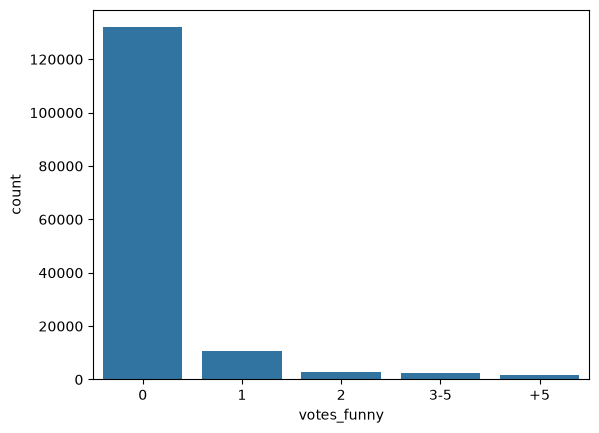

In [ ]:
# quantos leitores marcaram o review como engraçado (reação de quem leu)
faixas = pd.cut(df['votes_funny'], [-1, 0, 1, 2, 5, 100000],
                labels=['0', '1', '2', '3-5', '+5'])
sns.countplot(x=faixas)
print(df['votes_funny'].describe())
print('skew:', round(df['votes_funny'].skew(), 2), '| curtose:', round(df['votes_funny'].kurt(), 2))

**votes_funny**: Ainda mais concentrada, com 88,3% de zeros, **assimetria** 62,5 e **curtose** 6.150. **Média** 0,41 e **desvio padrão** 4,5: praticamente constante, com pouca informação aproveitável.

Seguem para a multivariada as variáveis com variabilidade suficiente e ligação plausível com a pergunta de pesquisa. `continued` é o alvo e aparece em todos os cruzamentos. `playtime_hours_at_review` e `review_len` medem engajamento e esforço no texto. `voted_up`, `steam_purchase`, `received_for_free` e `written_during_early_access` descrevem a opinião e a forma de aquisição. `game` e `game_age_years` entram porque a retenção varia de 30% a 84% entre os jogos. `author_num_games_owned` e `profile_hidden` descrevem o perfil do autor. `days_to_collection` entra para testar se a janela de observação enviesa o alvo.

As demais ficam de fora. `votes_up`, `votes_funny` e `comment_count` medem a reação de quem leu, não o comportamento do autor, e têm de 70% a 95% de zeros. `reviews_per_game` é indefinida para 54% da base e `author_num_reviews` é redundante com `author_num_games_owned`. `created_year` reflete o desenho da coleta e `created_weekday` separa pouco mais de um ponto percentual de retenção. `review_edited` e `mentions_bug` separam cerca de cinco pontos percentuais, pouco para um cruzamento próprio, mas seguem como features para a modelagem.

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

In [40]:
# again, feel free to place as many cells to plot the visualizations,
# as well as describe to the main findings

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

In [41]:
# your code goes here

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

```
Add your text here.
```

# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
6. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [42]:
# use as many cells as needed

# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.